In [ ]:
import pickle
import os
DATASET_NAMES = ["mmlu_high_school", "mmlu_professional", "ARC-Challenge", "ARC-Easy", "sms_spam"]
MODEL_NAMES = ["Apertus-8B-Instruct-2509", "Llama-3.1-8B-Instruct"]
ENDINGS = ["hs", "pro", "arc_challenge"]
DS_INDEX = 1
MODEL_INDEX = 1
DATASET_NAME = DATASET_NAMES[DS_INDEX]
MODEL = MODEL_NAMES[MODEL_INDEX]
TRANSFORM = True
ENDING = "transform" if TRANSFORM else "leave"


path = f"/users/astepancic/projects/apertus-probes/scratch/mera-runs/{DATASET_NAME}/{MODEL}/df_probes_{ENDING}.pkl"
# Expand $SCRATCH environment variable if present in the path

with open(path, 'rb') as file:
    results = pickle.load(file)
results.head()


,Dataset,LLM_model,Task,Model,Inputs,Error-Type,Layer,Residuals,Coefficients,Nonzero-Features,...,AUCROC,Accuracy,Accuracy (Balanced),Dummy-AUCROC,Dummy-Accuracy,Dummy-Accuracy (Balanced),RMSE,MSE,Dummy-RMSE,Dummy-MSE
0,mmlu_high_school,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.619562,0.651986,0.619562,0.5,0.580311,0.5,NaN,NaN,NaN,NaN
1,mmlu_high_school,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.597805,0.638169,0.597805,0.5,0.603627,0.5,NaN,NaN,NaN,NaN
2,mmlu_high_school,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.613554,0.645941,0.613554,0.5,0.582902,0.5,NaN,NaN,NaN,NaN
3,mmlu_high_school,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.624690,0.658031,0.624690,0.5,0.582038,0.5,NaN,NaN,NaN,NaN
4,mmlu_high_school,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.623802,0.664940,0.623802,0.5,0.596718,0.5,NaN,NaN,NaN,NaN


Plot saved to rmse_comparison_Llama-3.1-8B-Instruct_transform_exact.png
Plot saved to rmse_comparison_Llama-3.1-8B-Instruct_transform_last.png


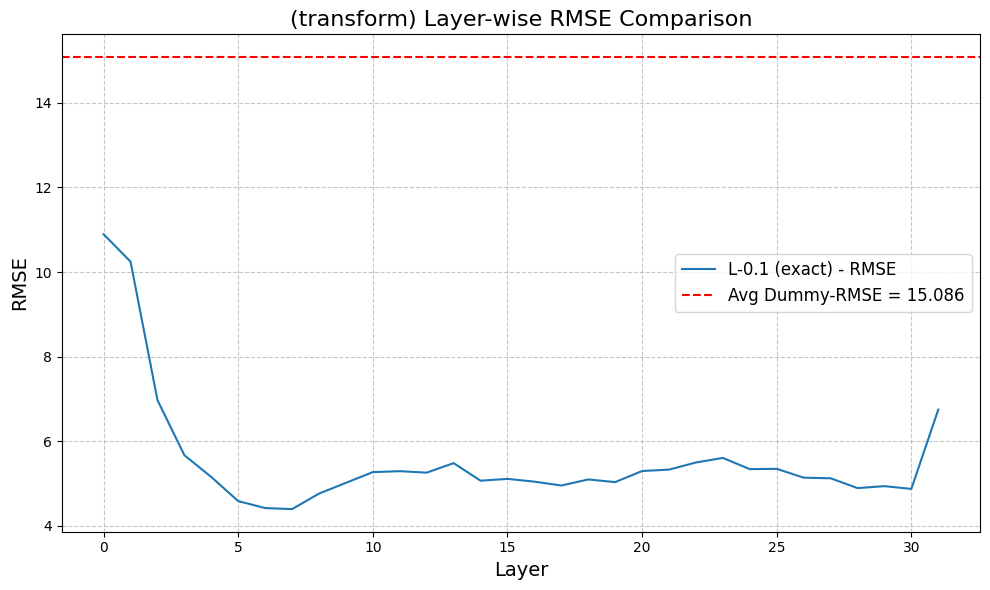

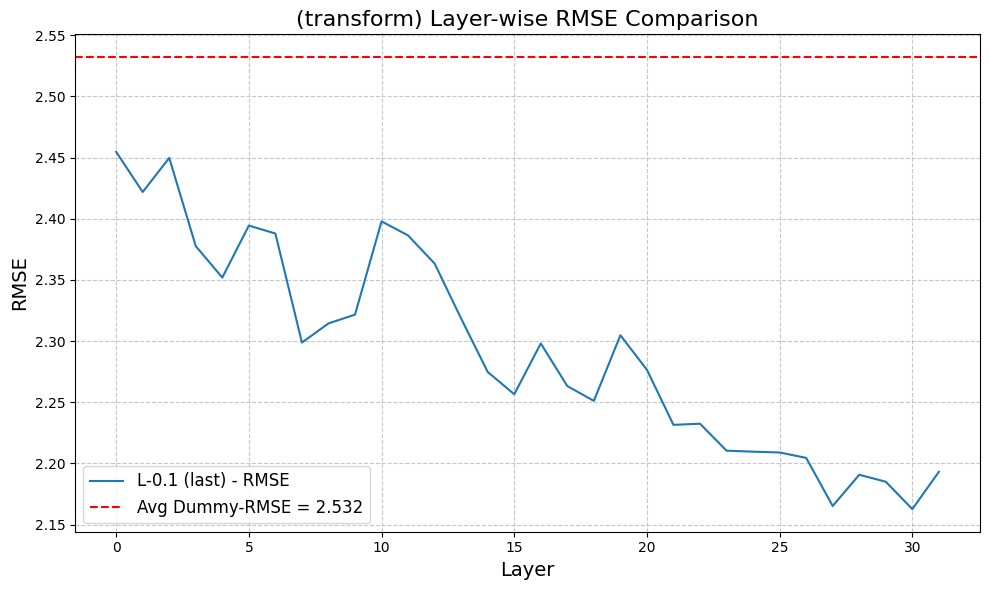

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_rmse_comparison(grouped_data, models_to_plot, token_positions, save_path=None):
    plt.figure(figsize=(10, 6))

    # One avg Dummy-RMSE across the selected models/token positions
    mask = grouped_data['Token-Pos'].isin(token_positions)
    if models_to_plot is not None:
        mask &= grouped_data['Model'].isin(models_to_plot)
    dummy_rmse = pd.to_numeric(grouped_data.loc[mask, 'Dummy-RMSE'], errors='coerce').mean()

    for model in models_to_plot:
        for token_pos in token_positions:
            group = grouped_data[(grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)]
            if group.empty:
                continue

            # Mean RMSE per layer
            layer_rmse = group.groupby('Layer')['RMSE'].mean()
            if layer_rmse.empty:
                continue

            plt.plot(
                layer_rmse.index,
                layer_rmse.values,
                label=f'{model} ({token_pos}) - RMSE'
            )

    # Plot a single Dummy-RMSE line
    if not np.isnan(dummy_rmse):
        plt.axhline(y=dummy_rmse, color='red', linestyle='--', linewidth=1.5,
                    label=f'Avg Dummy-RMSE = {dummy_rmse:.3f}')

    plt.title(f'({ENDING}) Layer-wise RMSE Comparison', fontsize=16)
    plt.xlabel('Layer', fontsize=14)
    plt.ylabel('RMSE', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")

# Example usage
models_to_plot = ['L-0.1']
token_positions = ['exact'] # Replace with actual token positions
save_path = f"rmse_comparison_{MODEL}_{ENDING}"
plot_rmse_comparison(results, models_to_plot, token_positions, save_path=save_path +'_exact.png')
token_positions = ['last']
plot_rmse_comparison(results, models_to_plot, token_positions, save_path=save_path + '_last.png')


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_rmse_both_models(grouped_data: pd.DataFrame, models_to_plot, token_positions, title=None, save_path=None):
    # Ensure list-like
    models_to_plot = list(models_to_plot)
    token_positions = list(token_positions)

    npos = len(token_positions)
    fig, axes = plt.subplots(1 if npos == 1 else npos, 1, figsize=(10, 6 if npos == 1 else 5*npos), squeeze=False)
    axes = axes.ravel()

    for ax, token_pos in zip(axes, token_positions):
        # Dummy-RMSE across selected models for this token position
        mask = (grouped_data['Token-Pos'] == token_pos) & (grouped_data['Model'].isin(models_to_plot))
        dummy_rmse = pd.to_numeric(grouped_data.loc[mask, 'Dummy-RMSE'], errors='coerce').mean()

        # Plot each model’s RMSE per layer
        for model in models_to_plot:
            gmask = (grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)
            group = grouped_data.loc[gmask]
            if group.empty:
                continue

            layer_rmse = (
                group.groupby('Layer')['RMSE']
                .apply(lambda s: pd.to_numeric(s, errors='coerce').mean())
                .sort_index()
            )
            if layer_rmse.empty:
                continue

            ax.plot(layer_rmse.index, layer_rmse.values, marker='o', linewidth=1.5, label=f'{model}')

        # Single Dummy-RMSE line
        if not np.isnan(dummy_rmse):
            ax.axhline(y=dummy_rmse, color='red', linestyle='--', linewidth=1.5,
                       label=f'Avg Dummy-RMSE = {dummy_rmse:.3f}')

        ax.set_title(f'{title or "Layer-wise RMSE"} — Token-Pos: {token_pos}', fontsize=13)
        ax.set_xlabel('Layer')
        ax.set_ylabel('RMSE')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(fontsize=10)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")
    return fig